In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df=pd.read_csv("netflix_titles.csv")

In [ ]:
df

##What is the total number of records and columns in the dataset?

In [ ]:
#What is the total number of records and columns in the dataset?
row,col=df.shape
print(f"Number of rows is: {row}")
print(f"Number of columns is: {col}")

Answer:
The dataset contains 8807 records and 12 columns.

##What are the data types of each column?

In [ ]:
print(df.dtypes)

Answer:
Most columns in the dataset are of 'object' data type, indicating categorical or textual data (e.g., title, director, cast, country, rating).   
The 'release_year' column is of integer type (int64), representing numerical year values.

##How many missing values are present in each column?

In [ ]:
print(df.isnull().sum())
print("Total Misising values:",df.isnull().sum().sum())

Answer:
The dataset contains a total of 4307 missing values.

The columns with missing values are:
- director: 2634 missing values
- cast: 825 missing values
- country: 831 missing values
- date_added: 10 missing values
- rating: 4 missing values
- duration: 3 missing values

These columns require data cleaning.

##Which columns have missing values and how did you handle them?

In [ ]:
df=df.dropna(subset=["date_added"])
df=df.fillna("Not Available")

Answer: As there is approx 4307 missing values, using .dropna() will be not appropriate a huge chunk of data (many rows) will be deleted, instead we use .fill() to replace the missing values with "Not Available" for categorical data like "director","cast","country","rating" and "duration".

But for "date_added" we have only 10 missing values so wecan drop them.

##Convert the date_added column into proper datetime format

In [ ]:
df["date_added"]=pd.to_datetime(df["date_added"].str.strip())

In [ ]:
df["Month_added"]=df["date_added"].dt.month_name()
df["Month_number"]=df["date_added"].dt.month
df["Year_added"]=df["date_added"].dt.year
df["Day"]=df["date_added"].dt.day

Answer:
The 'date_added' column was originally in string format, so it was converted into datetime format using the pandas to_datetime() function after removing any extra spaces.

After conversion, new features were extracted from the column, including:
- Month name
- Month number
- Year
- Day

These new features help in performing time-based analysis more effectively.

##What is the distribution of Movies vs TV Shows?

In [ ]:
plt.figure(figsize=(10,8))
sns.countplot(x="type",data=df)
plt.title("Movie Vs TV Shows")
plt.xlabel("Type of content")
plt.ylabel("Number of Movies/TV Shows")

Answer: A countplot was used to visualize the distribution of Movies and TV Shows, as the 'type' column is categorical.
From the plot, we can see that the number of movies is way more than TV shows

Conclusion: Movies dominate the Netflix content library, indicating that Netflix focuses more on movie content compared to TV Shows.

##Which are the top 10 most common genres on Netflix and plot a bar chart and analyze?

As one movie can be of multiple genre, we will exapnd the genre column i.e "listed_in"

In [ ]:
df_genre=df.copy()
df_genre["Genre"]=df_genre["listed_in"].str.split(",")
df_genre=df_genre.explode("Genre")
df_genre=df_genre.dropna(subset=["Genre"])
df_genre["Genre"]=df_genre["Genre"].astype(str).str.strip()

#Now finding the top 10 most common genre
a=df_genre["Genre"].value_counts().head(10)
print(a)

sns.barplot(x=a.values,y=a.index)
plt.title("Top 10 most common genres on Netflix")
plt.xlabel("Total number of Movies/TV shows from each genre")
plt.ylabel("Genre")


Answer:
The 'listed_in' column contains multiple genres for each entry, so it was first split and expanded using the explode() function to analyze each genre individually.

From the bar chart, it is observed that "International Movies" is the most common genre on Netflix, followed by other genres like Drama and Comedies.

##Which countries produce the most content on Netflix?

In [ ]:
df_country=df.copy()
df_country = df_country[df_country["country"] != "Not Available"]
df_country["Countries"]=df_country["country"].str.split(",")
df_country=df_country.explode("Countries")
df_country=df_country.dropna(subset=["Countries"]) #drop all the missing countries column
df_country["Countries"]=df_country["Countries"].astype(str).str.strip()

a=df_country["Countries"].value_counts().head(10)
print(a)
sns.barplot(x=a.values,y=a.index)
plt.title("Top 10 most content producing countries")
plt.xlabel("Number of contents")
plt.ylabel("Countries")

Answer:
A copy of the original dataframe was created to avoid modifying the original data.Rows where the 'country' column had the value "Not Available" were removed, as they represent missing or invalid data

After this, the "country" column contains multiple country for each entry, so it was first split and expanded using the explode() function to analyze each country individually.

From the barchart, it is observed that United States produces the most number of content followed by India and United Kingdom.

##What is the most common content rating?

In [ ]:
df_content=df.copy()
df_content=df_content[(df_content["rating"]!="Not Available")]
a=df_content["rating"].value_counts()
print("Most common content rating is:",a.idxmax())

Answer: A copy of original dataframe is created to avoid modifying the original data. Rows where the "rating" column had value "Not Available" were removed, as they represent missing or invalid data.

The most common content rating on Netflix is TV-MA.

##How has content addition changed over the years?

In [ ]:
a=df["Year_added"].value_counts().sort_index()
print(a)
sns.barplot(x=a.index,y=a.values)
plt.tight_layout()
plt.title("Number of content added each year on Netflix")
plt.xlabel("Year")
plt.ylabel("Number of content")

Answer:
From the bar chart, it is observed that there was a gradual increase in content added to Netflix from 2008 to 2016. After that, there was a rapid growth in content additions, reaching a peak around 2019, followed by a slight decline.

##Which year had the highest number of content additions?

In [ ]:
a=df["Year_added"].value_counts()
print("Year:",a.idxmax())
print("Number of contents added:",a.max())

Answer:
The highest number of content additions occurred in the year 2019, with 2016 titles added.

##Which month sees the highest content addition?

In [ ]:
a=df["Month_added"].value_counts()
month=a.idxmax()
cont_add=a.max()
print("Month with highest number of content addition:",month)
print("Total number of content added:",cont_add)

Answer: The highest number of content additions occurred in July, with 827 titles added.

##What is the distribution of release years of content?

In [ ]:
plt.figure(figsize=(8,7))
sns.histplot(x="release_year",bins=50,data=df,kde=True)
plt.title("Distribution of release years of content")
plt.xlabel("Year of release")
plt.ylabel("Number of contents")


Answer:
The distribution of release years shows that most content available on Netflix is from recent years, particularly after 2000. There is a noticeable increase in content released after 2010.

##Who are the most frequent directors on Netflix?

In [ ]:
df_director=df.copy()
df_director=df_director[(df_director["director"]!="Not Available")]
df_director["director"]=df_director["director"].str.split(",")
df_director=df_director.explode("director")
df_director=df_director.dropna(subset=["director"])
df_director["director"]=df_director["director"].astype(str).str.strip()

a=df_director["director"].value_counts().head(10)
print(a)

director
Rajiv Chilaka          22
Jan Suter              21
Raúl Campos            19
Suhas Kadav            16
Marcus Raboy           16
Jay Karas              15
Cathy Garcia-Molina    13
Martin Scorsese        12
Youssef Chahine        12
Jay Chapman            12
Name: count, dtype: int64


Answer: A copy of the original dataframe was created to avoid modifying the original data. Rows where the 'director' column had the value "Not Available" were removed, as they represent missing or invalid data.

The 'director' column contains multiple directors for some movies, so it was first split and expanded using the explode() function to analyze each director individually.

The top 10 frequent directors on Netflix are:

Rajiv Chilaka: 22

Jan Suter: 21

Raúl Campos: 19

Suhas Kadav: 16

Marcus Raboy: 16

Jay Karas: 15

Cathy Garcia-Molina: 13

Martin Scorsese: 12

Youssef Chahine: 12

Jay Chapman: 12

##Which actors appear most frequently?

In [ ]:
df_actor=df.copy()
df_actor=df_actor.loc[(df_actor["cast"]!="Not Available")]

df_actor["cast"]=df_actor["cast"].str.split(",")
df_actor=df_actor.explode("cast")
df_actor=df_actor.dropna(subset=["cast"])
df_actor["cast"]=df_actor["cast"].astype(str).str.strip()

a=df_actor["cast"].value_counts().head(10)
print(a)

,count
cast,
Anupam Kher,43
Shah Rukh Khan,35
Julie Tejwani,33
Takahiro Sakurai,32
Naseeruddin Shah,32
Rupa Bhimani,31
Om Puri,30
Akshay Kumar,30
Yuki Kaji,29


Answer: A copy of the original dataframe is created to avoid modifying the original data.

Rows where "cast" column had the value "Not Available" were removed as they represent missing or invalid data.
The "cast" column contains multiple names for every movie, so it was first split and expanded using the explode() function to analyze each actor individually.

The top 10 frequent actors on Netflix are:
Anupam Kher:	43

Shah Rukh Khan:	35

Julie Tejwani:	33

Takahiro Sakurai:	32

Naseeruddin Shah:	32

Rupa Bhimani:	31

Om Puri:	30

Akshay Kumar:	30

Yuki Kaji:	29

Amitabh Bachchan:	28


##Is there any relationship between content type and rating?

Text(4.722222222222216, 0.5, 'Rating')

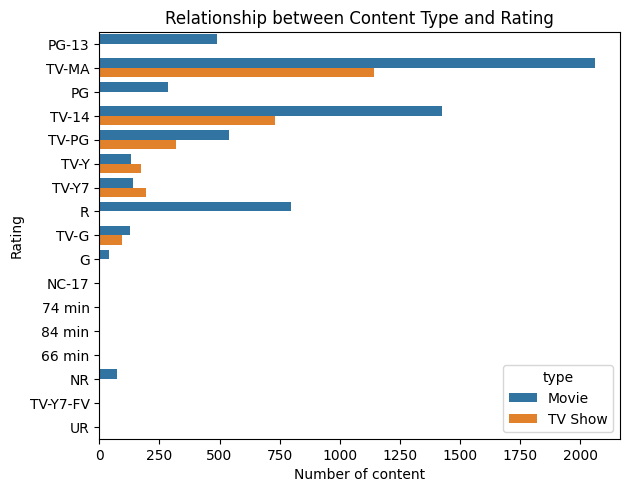

In [ ]:
df1=df.copy()
df1=df1.loc[(df1["rating"]!="Not Available")]
sns.countplot(y="rating",hue="type",data=df1)
plt.tight_layout()
plt.title("Relationship between Content Type and Rating")
plt.xlabel("Number of content")
plt.ylabel("Rating")

Answer:
A countplot with 'rating' on the y-axis and 'type' as hue was used to analyze the relationship between content type and rating.

From the plot, it is observed that certain ratings such as TV-MA and TV-14 are more common in both Movies and TV Shows. However, Movies tend to dominate across most rating categories, especially in mature ratings.

This indicates that both Movies and TV Shows on Netflix are largely targeted toward mature audiences, with Movies being more prevalent overall.

##Which genre is most common for Movies vs TV Shows?

Text(-111.65277777777779, 0.5, 'Genres')

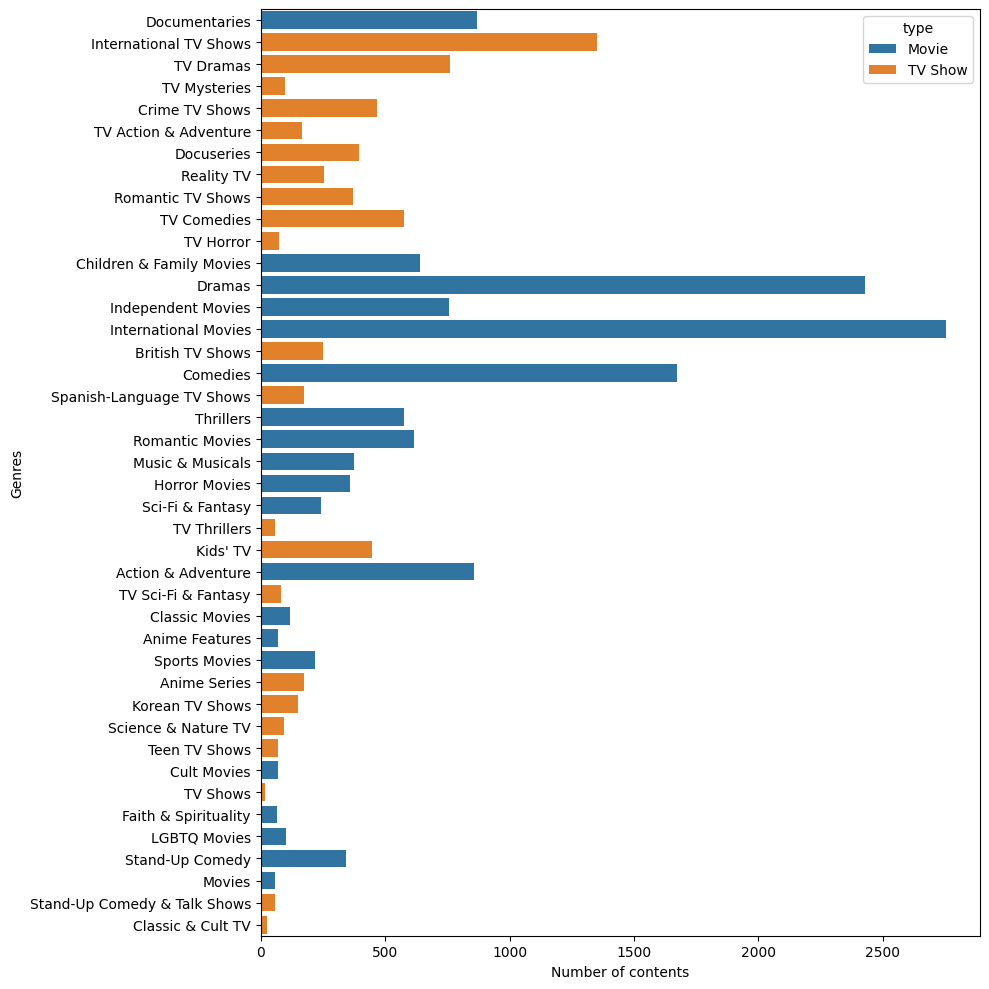

In [ ]:
df_genre=df.copy()
df_genre=df_genre.loc[(df_genre["listed_in"]!="Not Available")]
df_genre["listed_in"]=df_genre["listed_in"].str.split(",")
df_genre=df_genre.explode("listed_in")
df_genre=df_genre.dropna(subset=["listed_in"])
df_genre["listed_in"]=df_genre["listed_in"].astype(str).str.strip()

plt.figure(figsize=(10,10))
sns.countplot(y="listed_in",hue="type",data=df_genre)
plt.tight_layout()
plt.xlabel("Number of contents")
plt.ylabel("Genres")

Answer: From the bar chart,we observed that "International Movies" is the most common genre for Movies, and "International TV Shows" is the most common genre for TV Shows

In [ ]:
df


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,Month_added,Month_number,Year_added,Day
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,Not Available,United States,2021-09-25,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",September,9,2021,25
1,s2,TV Show,Blood & Water,Not Available,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",September,9,2021,24
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",Not Available,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...,September,9,2021,24
3,s4,TV Show,Jailbirds New Orleans,Not Available,Not Available,Not Available,2021-09-24,2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo...",September,9,2021,24
4,s5,TV Show,Kota Factory,Not Available,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...,September,9,2021,24
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8802,s8803,Movie,Zodiac,David Fincher,"Mark Ruffalo, Jake Gyllenhaal, Robert Downey J...",United States,2019-11-20,2007,R,158 min,"Cult Movies, Dramas, Thrillers","A political cartoonist, a crime reporter and a...",November,11,2019,20
8803,s8804,TV Show,Zombie Dumb,Not Available,Not Available,Not Available,2019-07-01,2018,TV-Y7,2 Seasons,"Kids' TV, Korean TV Shows, TV Comedies","While living alone in a spooky town, a young g...",July,7,2019,1
8804,s8805,Movie,Zombieland,Ruben Fleischer,"Jesse Eisenberg, Woody Harrelson, Emma Stone, ...",United States,2019-11-01,2009,R,88 min,"Comedies, Horror Movies",Looking to survive in a world taken over by zo...,November,11,2019,1
8805,s8806,Movie,Zoom,Peter Hewitt,"Tim Allen, Courteney Cox, Chevy Chase, Kate Ma...",United States,2020-01-11,2006,PG,88 min,"Children & Family Movies, Comedies","Dragged from civilian life, a former superhero...",January,1,2020,11


##How has Netflix expanded globally over time?

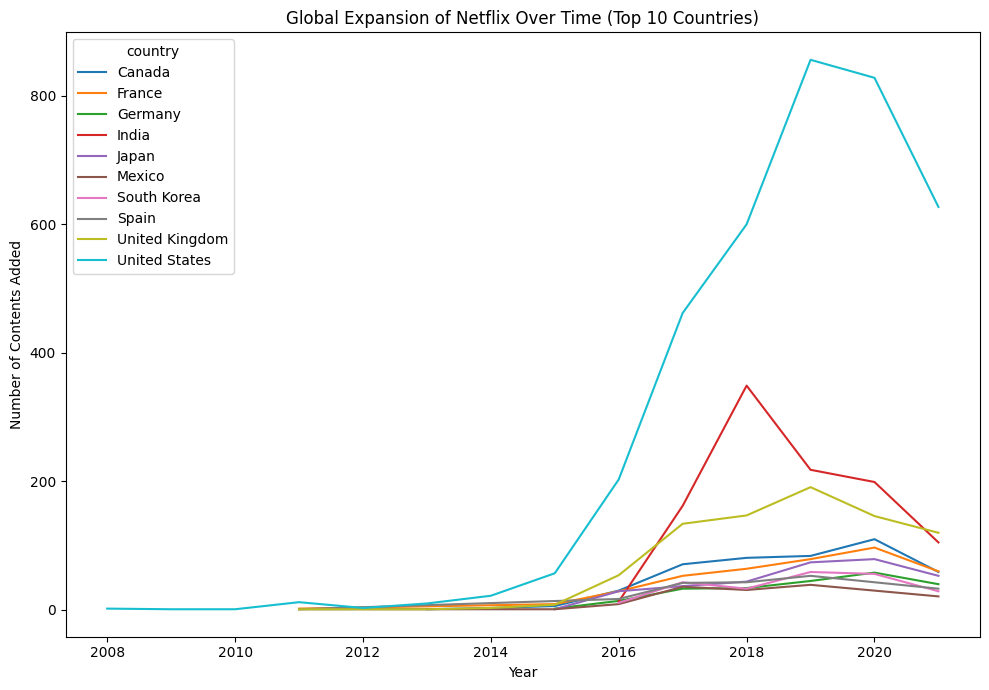

In [ ]:
df_country2=df.copy()
df_country2=df_country2.loc[(df_country2["country"]!="Not Available")]
df_country2["country"]=df_country2["country"].str.split(",")
df_country2=df_country2.explode("country")
df_country2=df_country2.dropna(subset=["country"])
df_country2["country"]=df_country2["country"].astype(str).str.strip()

top10 = df_country2["country"].value_counts().head(10).index
df_country2 = df_country2[df_country2["country"].isin(top10)]
# Group by country and year
grouped = df_country2.groupby(["country", "Year_added"]).size().reset_index(name="count")

# Plot
plt.figure(figsize=(10,7))
sns.lineplot(data=grouped, x="Year_added", y="count", hue="country")
plt.title("Global Expansion of Netflix Over Time (Top 10 Countries)")
plt.xlabel("Year")
plt.ylabel("Number of Contents Added")
plt.tight_layout()

#Answer:
To analyze Netflix's global expansion, the 'country' column was split and expanded to consider each country individually. The data was then analyzed across different years using the 'Year_added' column.

From the analysis, it is observed that content production has increased over time across multiple countries, especially in top contributing countries like the United States, India, and the United Kingdom.

This indicates that Netflix has expanded globally by increasing content availability from different countries over the years.

##Final Insights

1. Movies dominate Netflix content, indicating that the platform focuses more on movie production compared to TV Shows.

2. "International Movies" and "International TV Shows" are among the most common genres, highlighting Netflix's strong global content strategy.

3. The United States contributes the highest number of titles, followed by countries like India and the United Kingdom, showing a diverse international presence.
4. Content additions increased significantly after 2015, reaching a peak around 2019, which reflects Netflix’s rapid expansion during this period.

5. The majority of content available on Netflix is from recent years, especially after 2000, showing a focus on modern content.

6. The most common rating is TV-MA, indicating that a large portion of Netflix content is targeted toward mature audiences.

##Conclusion

Conclusion:

This project analyzed Netflix's content dataset to understand patterns in content distribution, genres, countries, and trends over time. The analysis revealed that Netflix has significantly expanded its content library, especially after 2015, with a strong focus on international and modern content.

The platform is dominated by movies and caters largely to mature audiences. Additionally, the presence of content from multiple countries highlights Netflix’s global reach and strategy.

Overall, this analysis demonstrates how data can be used to uncover meaningful insights about content trends and platform growth.